<a href="https://colab.research.google.com/github/pradervonsky/vbig-lab/blob/main/evaluation/generation-12_InternVL3-1B-hf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVLM Dashboard Insight Generation

## Initial Steps

In [1]:
!pip install -q supabase pillow requests torch torchvision einops

In [2]:
import os
import time
import requests
import torch
from io import BytesIO
from PIL import Image
from supabase import create_client, Client
from google.colab import userdata
from huggingface_hub import login

In [3]:
# Supabase credentials
SUPABASE_URL = userdata.get("SUPABASE_URL")
SUPABASE_KEY = userdata.get("SUPABASE_KEY")
HF_TOKEN     = userdata.get("HF_TOKEN")

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Supabase client initialised.")

login(token=HF_TOKEN)
print("HuggingFace login successful.")

Supabase client initialised.
HuggingFace login successful.


In [4]:
# Pull qualifying metadata_ids from human_insights
hi_response = supabase.table("human_insights") \
    .select("metadata_id") \
    .eq("expected_dataset", True) \
    .is_("rejection_reason", "null") \
    .execute()

qualified_ids = list({row["metadata_id"] for row in hi_response.data})
print(f"Qualified dashboards: {len(qualified_ids)}")

# Pull metadata only for those ids
response = supabase.table("metadata") \
    .select("id, bucket_path") \
    .in_("id", qualified_ids) \
    .execute()
dashboards = response.data

print(f"Loaded {len(dashboards)} dashboards.")
print("Sample record:", dashboards[0] if dashboards else "(empty)")

Qualified dashboards: 40
Loaded 40 dashboards.
Sample record: {'id': 'abee2e83-6384-4c23-abfd-e5ede8b5a7bf', 'bucket_path': 'screenshots/abee2e83-6384-4c23-abfd-e5ede8b5a7bf.png'}


In [5]:
# Build public image URL from bucket_path
def build_image_url(bucket_path: str) -> str:
    return f"{SUPABASE_URL}/storage/v1/object/public/superstore/{bucket_path}"


# Fetch image from URL and return a PIL Image
def fetch_image(url: str) -> Image.Image:
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content)).convert("RGB")


# Extract model identity from a loaded model object
def get_model_meta(model, hf_id=None):
    cfg   = getattr(model, "config", None)
    hf_id = hf_id or getattr(cfg, "_name_or_path", None)
    name  = hf_id.split("/")[-1] if hf_id else None
    return {"model_name": name, "model_hf_id": hf_id}

In [6]:
# Prompt
PROMPT = """
You are a senior BI analyst generating structured insights for a business intelligence dashboard.
Think step-by-step: first extract visible quantitative facts, then identify visual patterns, then derive business implications.

Before writing any chart analysis, count the number of distinct charts visible in the dashboard and write: 'Chart count: N'.
Then produce exactly N chart analyses and no more.
Analyze chart-by-chart in Z-pattern (left to right, top to bottom).
If there are scoreboard/scorecard charts (e.g., sales, profit, orders, customers, etc), treat them as the first chart as one single chart with the title of "Scoreboard Overview".
Once grouped into Scoreboard Overview, those KPI panels are fully analyzed and must never appear again as individual charts anywhere in your output.
If there are no scoreboard/scorecard charts, proceed with writing the first chart available.
Do not treat UI labels, navigation tabs, filters, or sidebar controls as charts.
For each chart, write exactly:
L2: one sentence reporting only values explicitly shown or labeled: highest/lowest value, comparison, ranking, or proportion only. Do not compute anything not displayed in the image.
L3: one sentence describing a visual pattern: a direction, a shape, a gap, or an exception. Use natural language: "volatile", "dipped", "wider margin", "considerably far", "spread". Use hedging: "appears to", "seems to", "suggesting". Write NOT APPLICABLE if the chart is: a ranked table, a top-N list, or a gauge.
L4: one sentence connecting the pattern to business context or domain knowledge not visible in the chart. Must reference a specific value from L2 or a specific pattern from L3; never use generic phrases such as 'this could be due to' without grounding them in what was observed. Never restate what is already visible. Always required.

Output format:
Chart 1: [Title]
L2: [One sentence.]
L3: [One sentence.] or NOT APPLICABLE
L4: [One sentence.]

Chart 2: [Title]
L2: [One sentence.]
L3: [One sentence.] or NOT APPLICABLE
L4: [One sentence.]

Rules:
- Write EXACTLY 1 sentence per level per chart
- Skip navigation tabs, filters, sidebar controls, and dropdowns entierly
- Do not include axis labels, colors, or chart type names
- Immediately after writing your final chart analysis, write END OF ANALYSIS on its own line and generate no further text under any circumstances
"""

In [7]:
# Quick sanity check on the first dashboard
if dashboards:
    sample_url = build_image_url(dashboards[0]["bucket_path"])
    print("Sample URL:", sample_url)
    sample_img = fetch_image(sample_url)
    print("Image size:", sample_img.size)
    sample_img

Sample URL: https://olduvnqhykovcfbfouhe.supabase.co/storage/v1/object/public/superstore/screenshots/abee2e83-6384-4c23-abfd-e5ede8b5a7bf.png
Image size: (1200, 927)


---

## InternVL3-1B-hf
https://huggingface.co/OpenGVLab/InternVL3-1B-hf  

In [8]:
!pip install -q "transformers @ git+https://github.com/huggingface/transformers.git@main"

import transformers
print(transformers.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
5.8.0.dev0


In [9]:
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_HF_ID = "OpenGVLab/InternVL3-1B-hf"
device      = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_HF_ID, token=HF_TOKEN)
model     = AutoModelForImageTextToText.from_pretrained(
    MODEL_HF_ID,
    torch_dtype=torch.bfloat16,
    device_map=device,
    token=HF_TOKEN,
).eval()

meta = get_model_meta(model, hf_id=MODEL_HF_ID)
print(f"Loaded on {device}:")
print(f"  model_name:  {meta['model_name']}")
print(f"  model_hf_id: {meta['model_hf_id']}")

preprocessor_config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/733 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Loaded on cuda:
  model_name:  InternVL3-1B-hf
  model_hf_id: OpenGVLab/InternVL3-1B-hf


[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Dashboard ID:   abee2e83-6384-4c23-abfd-e5ede8b5a7bf
Inference time: 60811 ms

Output:
Chart 1: Sales Target
L2: Total Sales $733.2K, Target Sales $1.0M, Percent of Target 73.3%
L3: The sales target is set at $733.2K, with a target of $1.0M, indicating a significant gap between the two targets.
L4: This suggests a need for strategic adjustments to meet the sales target.

Chart 2: Sales by Sub-Category
L2: Phones 33%, Chairs 14%, Binders 47%, Storage 19%, Copiers 27%, Tables 0%
L3: The sales distribution shows a higher percentage for phones and chairs, indicating a strong focus on these categories.
L4: This could indicate a strategic shift towards these sub-categories to drive higher sales.

Chart 3: Sales by Segment
L2: Current Year $733,215, Previous Year $332K, CY Higher $332K, PY $45%
L3: The sales segment shows a significant increase from the previous year, with a higher percentage in the CY Higher category.
L4: This suggests a strong performance in the CY Higher segment, which cou

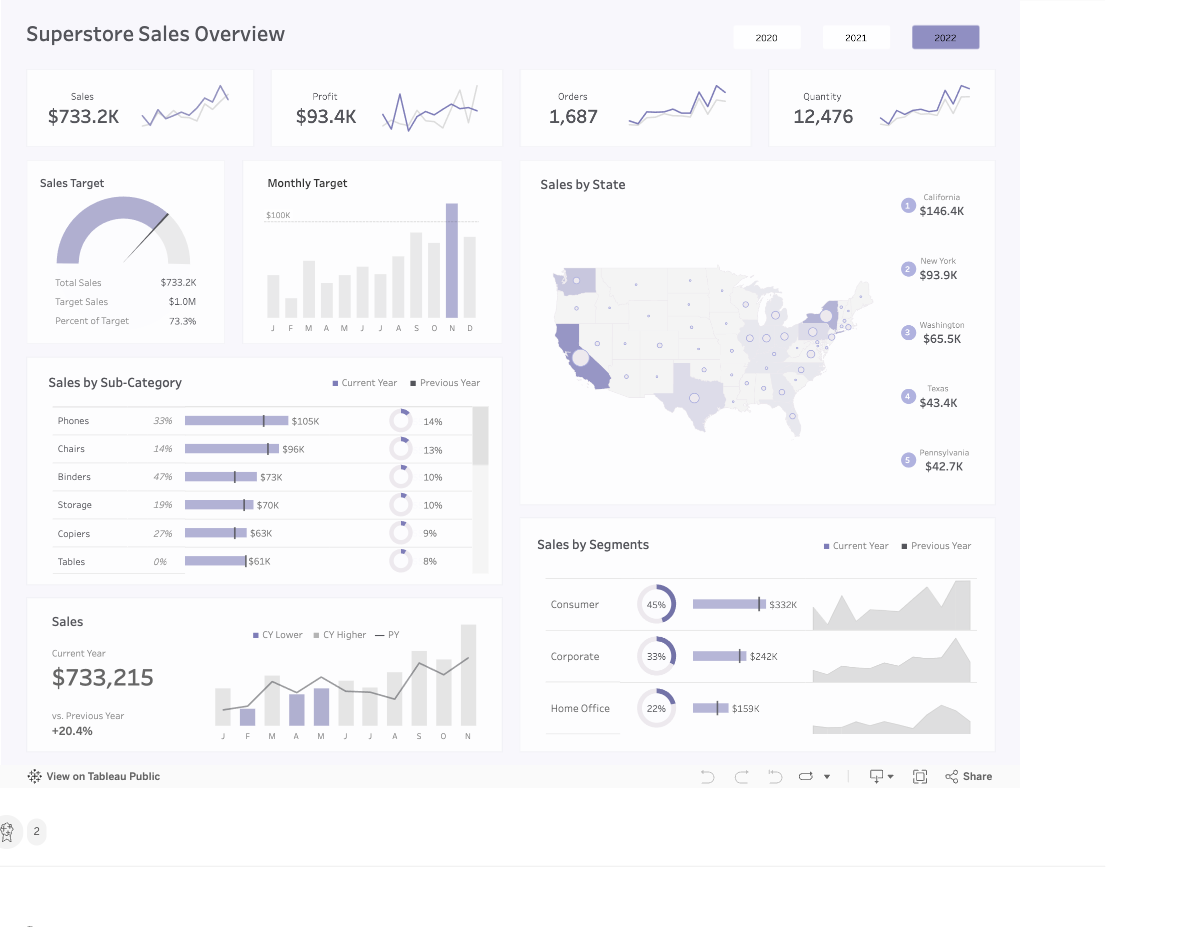

Saved to vlm_outputs.


In [10]:
test_dashboard = dashboards[0]
test_image_url = build_image_url(test_dashboard["bucket_path"])

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": test_image_url},
            {"type": "text", "text": PROMPT},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device, dtype=torch.bfloat16)

t0 = time.perf_counter()
with torch.no_grad():
    generate_ids = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
test_output = processor.decode(
    generate_ids[0, inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
)
test_ms = int((time.perf_counter() - t0) * 1000)

print(f"Dashboard ID:   {test_dashboard['id']}")
print(f"Inference time: {test_ms} ms")
print(f"\nOutput:\n{test_output}")
display(fetch_image(test_image_url))

supabase.table("vlm_outputs").upsert({
    "metadata_id":       test_dashboard["id"],
    **meta,
    "raw_output":        test_output,
    "inference_success": True,
    "error_message":     None,
    "inference_ms":      test_ms,
}, on_conflict="metadata_id,model_name").execute()

print("Saved to vlm_outputs.")